# 05 - Visualizacao da Segmentacao Bruta

Le os resumos persistidos pelo notebook 04, reconstrói a base linha a linha em memoria e gera um relatorio PDF com os graficos iniciais da segmentacao bruta.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams['figure.max_open_warning'] = 0
import pandas as pd
from IPython.display import display

root_dir = Path.cwd()
if not (root_dir / 'src').exists() and (root_dir.parent / 'src').exists():
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.analysis import MetricsCollector
from src.io.path_resolver import PathResolver
from src.repositories import (
    AnaliseSegmentacaoBrutaResumoExecucaoRepository,
    AnaliseSegmentacaoBrutaResumoModeloRepository,
    AnaliseSegmentacaoBrutaResumoTagRepository,
)
from src.visualization import (
    PdfReportSection,
    plot_metric_bars_by_model,
    plot_metric_by_execution_heatmap,
    plot_metric_distribution_by_model,
    plot_metric_distribution_by_tag,
    plot_metric_tag_comparison,
    save_pdf_report,
)


/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento dos resumos e da base linha a linha

Os resumos agregados sao lidos do SQLite. A base linha a linha e reconstruida apenas para os graficos de distribuicao.


In [2]:
def _registros_para_dataframe(registros, columns):
    return pd.DataFrame([{column: getattr(registro, column) for column in columns} for registro in registros])

metric_names = ['auprc', 'soft_dice', 'brier_score']
tags_prioritarias = [
    'tag_multi_bufalos',
    'tag_baixo_contraste',
    'tag_angulo_extremo',
    'tag_cortado',
    'tag_ocluido',
]
path_resolver = PathResolver.from_config()
report_output_path = Path(path_resolver.generated_dir) / '05_visualizacao_segmentacao_bruta.pdf'

collector = MetricsCollector(force_recalculate=False)
df_base = collector.collect_all_metrics()

resumo_modelo_repository = AnaliseSegmentacaoBrutaResumoModeloRepository()
resumo_execucao_repository = AnaliseSegmentacaoBrutaResumoExecucaoRepository()
resumo_tag_repository = AnaliseSegmentacaoBrutaResumoTagRepository()

df_resumo_modelo = _registros_para_dataframe(
    resumo_modelo_repository.list(),
    [
        'nome_modelo', 'metric_name', 'count', 'mean', 'median', 'std',
        'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'
    ],
)
df_resumo_execucao = _registros_para_dataframe(
    resumo_execucao_repository.list(),
    [
        'nome_modelo', 'execucao', 'metric_name', 'count', 'mean', 'median',
        'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'
    ],
)
df_resumo_tag = _registros_para_dataframe(
    resumo_tag_repository.list(),
    [
        'nome_modelo', 'tag_name', 'tag_value', 'metric_name', 'count', 'mean',
        'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'
    ],
)

print(f'Registros da base linha a linha: {len(df_base)}')
print(f'Resumo por modelo: {len(df_resumo_modelo)}')
print(f'Resumo por execucao: {len(df_resumo_execucao)}')
print(f'Resumo por tag: {len(df_resumo_tag)}')
print(f'PDF de saida: {report_output_path}')


✓ Métricas carregadas do SQLite
Registros da base linha a linha: 16254
Resumo por modelo: 42
Resumo por execucao: 126
Resumo por tag: 420
PDF de saida: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/05_visualizacao_segmentacao_bruta.pdf


## Visao geral por modelo

A tabela abaixo resume as medias e medianas por metrica, e os graficos ajudam a comparar os modelos de forma agregada.


metric_name,auprc,brier_score,soft_dice
nome_modelo,,,
birefnet-cod,0.985748,0.008668,0.977765
birefnet-dis,0.954597,0.013671,0.951632
birefnet-general,0.989522,0.006003,0.983332
birefnet-general-lite,0.986632,0.007568,0.981080
birefnet-hrsod,0.994105,0.006055,0.979967
birefnet-massive,0.986185,0.008849,0.975362
birefnet-portrait,0.987144,0.008421,0.977672
isnet-anime,0.813369,0.084392,0.574988
isnet-general-use,0.991877,0.009025,0.966871


metric_name,auprc,brier_score,soft_dice
nome_modelo,,,
birefnet-cod,0.994248,0.004391,0.983285
birefnet-dis,0.993188,0.004981,0.984975
birefnet-general,0.996545,0.002771,0.987330
birefnet-general-lite,0.994954,0.003172,0.986226
birefnet-hrsod,0.998958,0.002839,0.984180
birefnet-massive,0.997531,0.003669,0.984404
birefnet-portrait,0.996393,0.003623,0.983414
isnet-anime,0.945586,0.038951,0.701069
isnet-general-use,0.998212,0.005055,0.976465


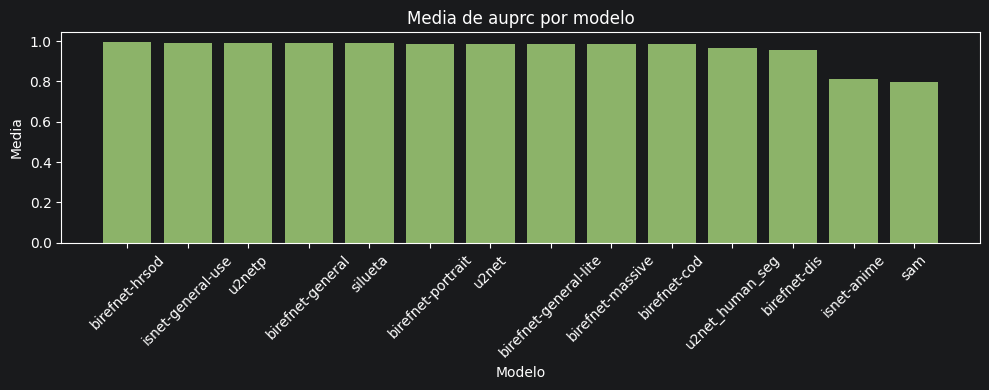

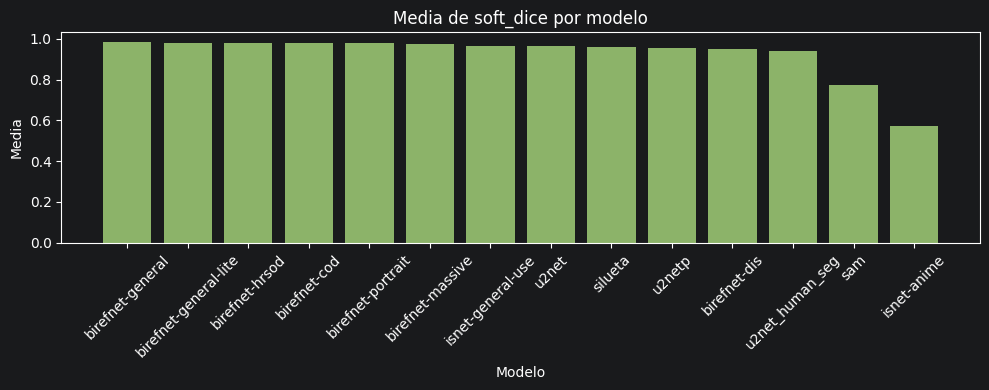

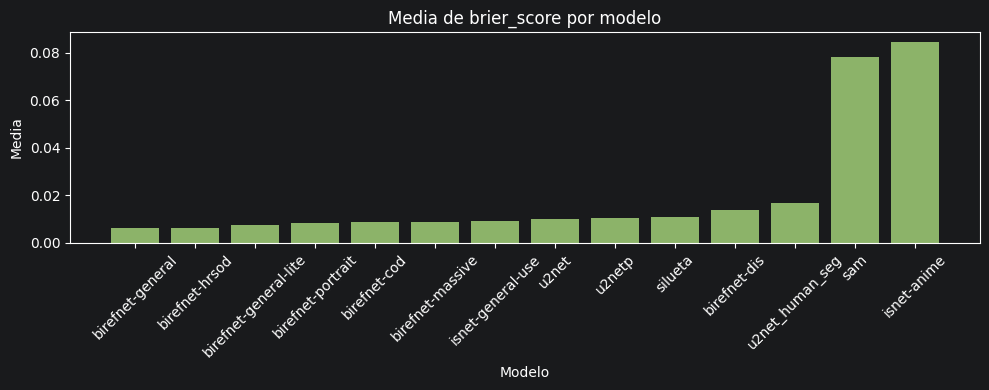

In [3]:
texto_visao_modelo = 'A tabela abaixo resume as medias e medianas por metrica, e os graficos ajudam a comparar os modelos de forma agregada.'
figures_visao_modelo = []

display(
    df_resumo_modelo.pivot(
        index='nome_modelo',
        columns='metric_name',
        values='mean',
    ).sort_index()
)

display(
    df_resumo_modelo.pivot(
        index='nome_modelo',
        columns='metric_name',
        values='median',
    ).sort_index()
)

for metric_name in metric_names:
    fig, _ = plot_metric_bars_by_model(df_resumo_modelo, metric_name)
    figures_visao_modelo.append(fig)
    plt.show()


## Estabilidade por execucao

Aqui avaliamos se o comportamento do modelo se mantem estavel entre as execucoes.


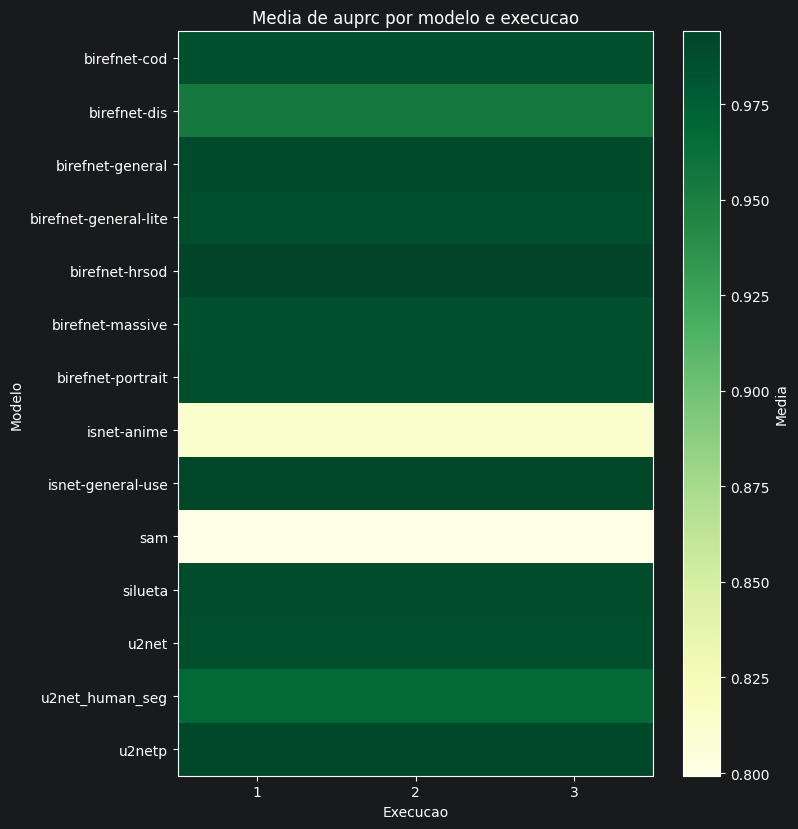

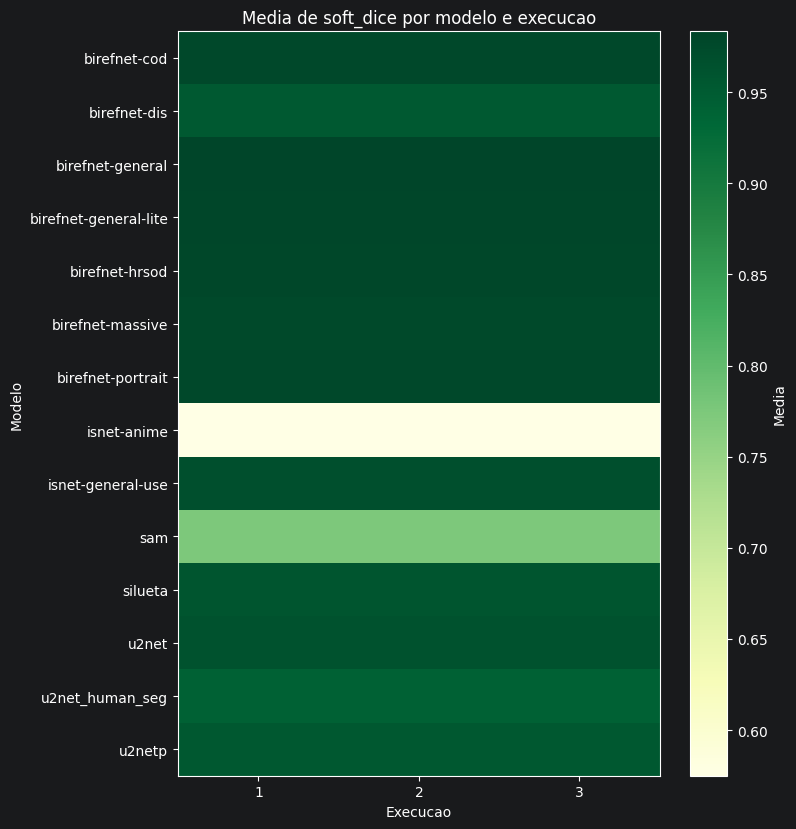

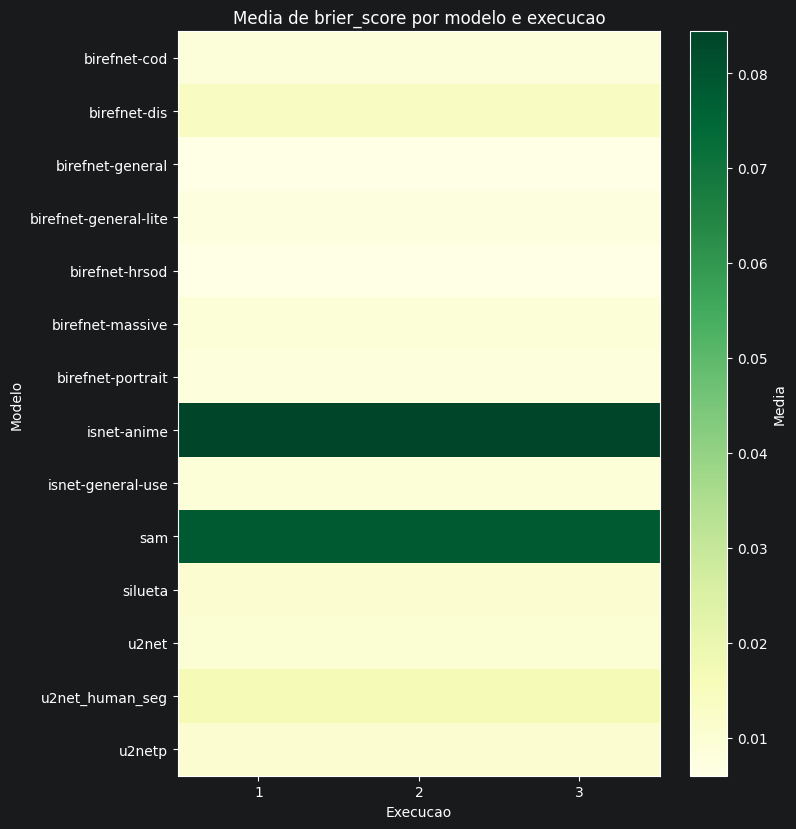

metric_name               auprc                     brier_score            \
execucao                      1         2         3           1         2   
nome_modelo                                                                 
birefnet-cod           0.985748  0.985748  0.985748    0.008668  0.008668   
birefnet-dis           0.954597  0.954597  0.954597    0.013671  0.013671   
birefnet-general       0.989522  0.989522  0.989522    0.006003  0.006003   
birefnet-general-lite  0.986632  0.986632  0.986632    0.007568  0.007568   
birefnet-hrsod         0.994105  0.994105  0.994105    0.006055  0.006055   
birefnet-massive       0.986185  0.986185  0.986185    0.008849  0.008849   
birefnet-portrait      0.987144  0.987144  0.987144    0.008421  0.008421   
isnet-anime            0.813368  0.813369  0.813368    0.084392  0.084392   
isnet-general-use      0.991876  0.991877  0.991876    0.009025  0.009025   
sam                    0.799289  0.799289  0.799289    0.078031  0.078031   
silueta                0.988375  0.988500  0.988375    0.010743  0.010744   
u2net                  0.986888  0.987225  0.986888    0.010015  0.010015   
u2net_human_seg        0.967595  0.967821  0.967595    0.016692  0.016692   
u2netp                 0.991592  0.991592  0.991592    0.010490  0.010490   

metric_name                     soft_dice                      
execucao                      3         1         2         3  
nome_modelo                                                    
birefnet-cod           0.008668  0.977765  0.977765  0.977765  
birefnet-dis           0.013671  0.951632  0.951632  0.951632  
birefnet-general       0.006003  0.983332  0.983332  0.983332  
birefnet-general-lite  0.007568  0.981080  0.981080  0.981080  
birefnet-hrsod         0.006055  0.979967  0.979967  0.979967  
birefnet-massive       0.008849  0.975362  0.975362  0.975362  
birefnet-portrait      0.008421  0.977672  0.977672  0.977672  
isnet-anime            0.084392  0.574988  0.574988  0.574988  
isnet-general-use      0.009025  0.966871  0.966871  0.966871  
sam                    0.078031  0.773514  0.773514  0.773514  
silueta                0.010743  0.958193  0.958235  0.958193  
u2net                  0.010015  0.963407  0.963494  0.963407  
u2net_human_seg        0.016692  0.940508  0.940555  0.940508  
u2netp                 0.010490  0.953905  0.953905  0.953905

In [4]:
texto_estabilidade_execucao = 'Aqui avaliamos se o comportamento do modelo se mantem estavel entre as execucoes.'
figures_estabilidade_execucao = []

for metric_name in metric_names:
    fig, _ = plot_metric_by_execution_heatmap(df_resumo_execucao, metric_name)
    figures_estabilidade_execucao.append(fig)
    plt.show()

display(
    df_resumo_execucao.pivot_table(
        index='nome_modelo',
        columns=['metric_name', 'execucao'],
        values='mean',
    ).sort_index()
)


## Impacto das tags

As tags entram como eixo explicativo do que degrada a segmentacao. O foco inicial esta nas tags mais provaveis de piorar a qualidade da mascara.


,nome_modelo,tag_name,tag_value,metric_name,mean,median,count
0,birefnet-cod,tag_angulo_extremo,False,auprc,0.986023,0.993975,1023
3,birefnet-cod,tag_angulo_extremo,True,auprc,0.983709,0.996021,138
1,birefnet-cod,tag_angulo_extremo,False,brier_score,0.008563,0.004877,1023
4,birefnet-cod,tag_angulo_extremo,True,brier_score,0.009446,0.003102,138
2,birefnet-cod,tag_angulo_extremo,False,soft_dice,0.977626,0.982801,1023
...,...,...,...,...,...,...,...
382,u2net_human_seg,tag_ocluido,False,brier_score,0.016692,0.008249,1161
383,u2net_human_seg,tag_ocluido,False,soft_dice,0.940524,0.965080,1161
411,u2netp,tag_ocluido,False,auprc,0.991592,0.997722,1161
412,u2netp,tag_ocluido,False,brier_score,0.010490,0.006415,1161


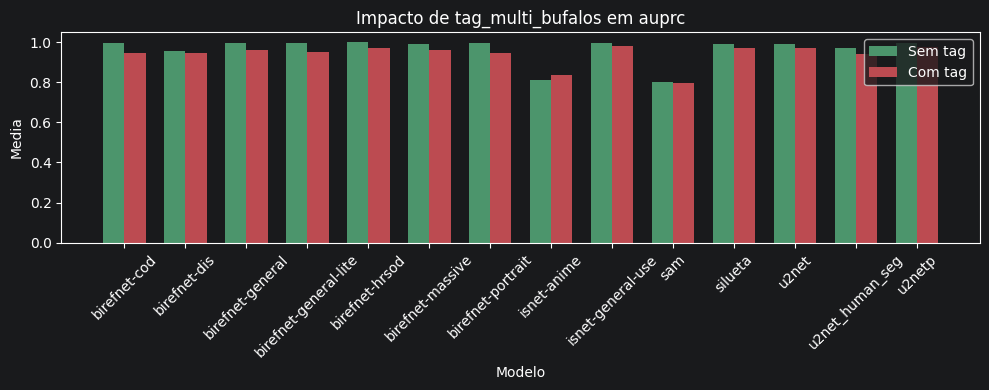

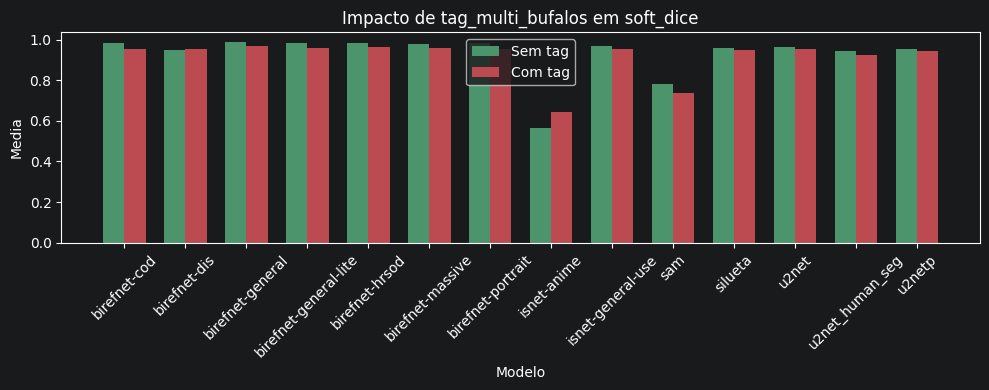

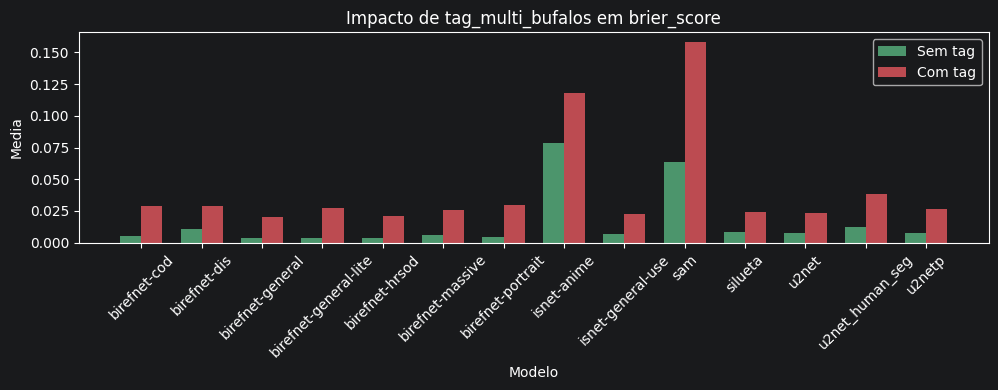

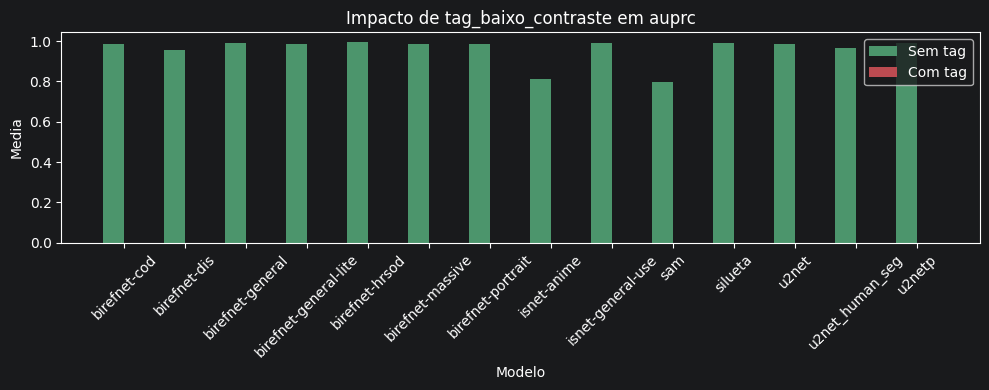

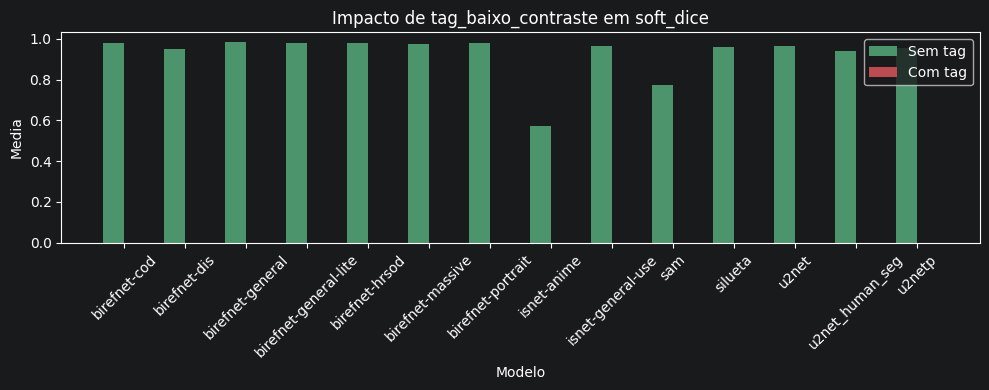

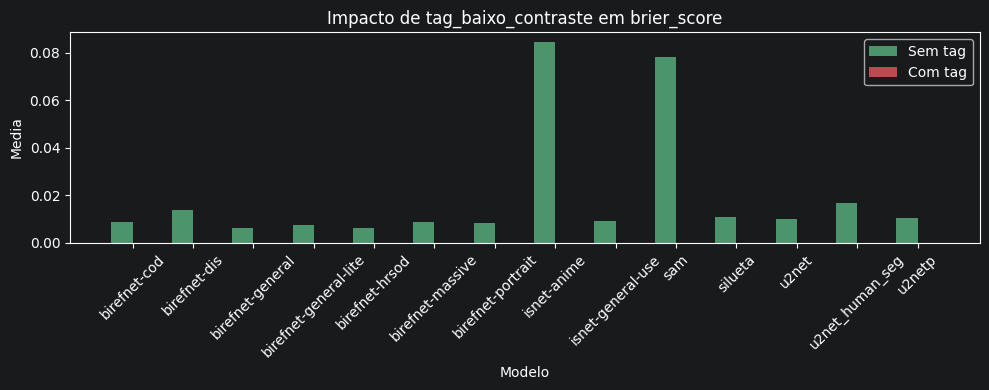

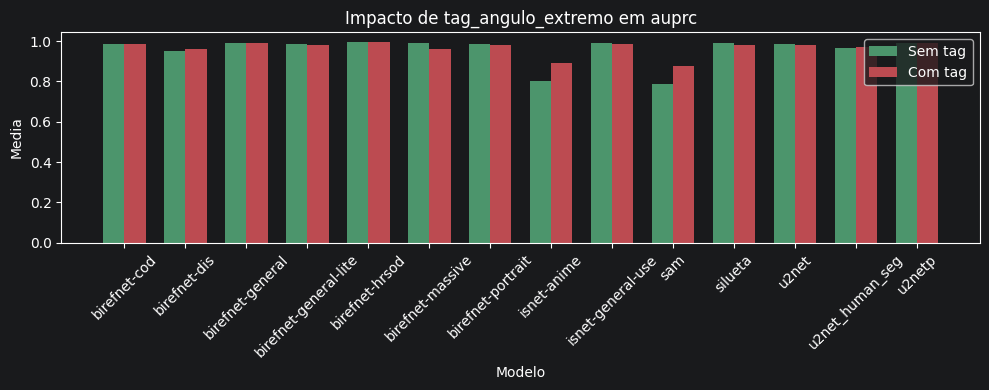

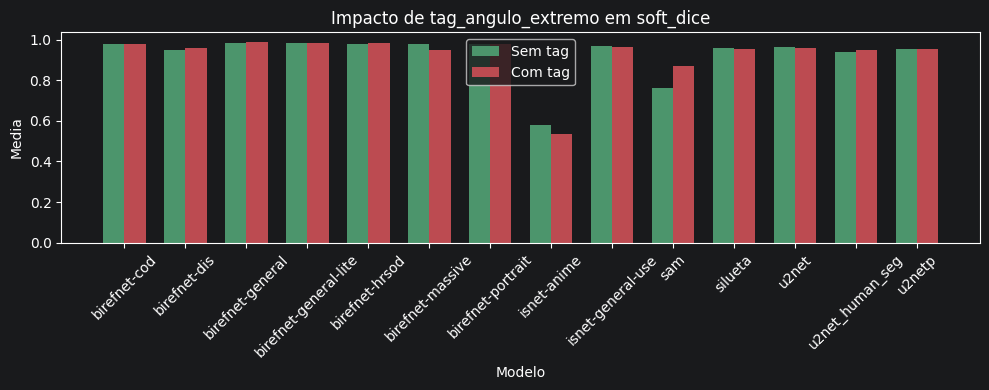

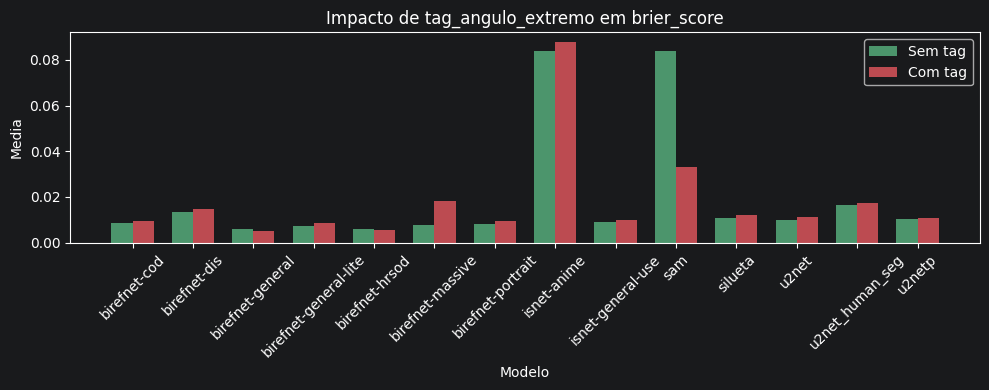

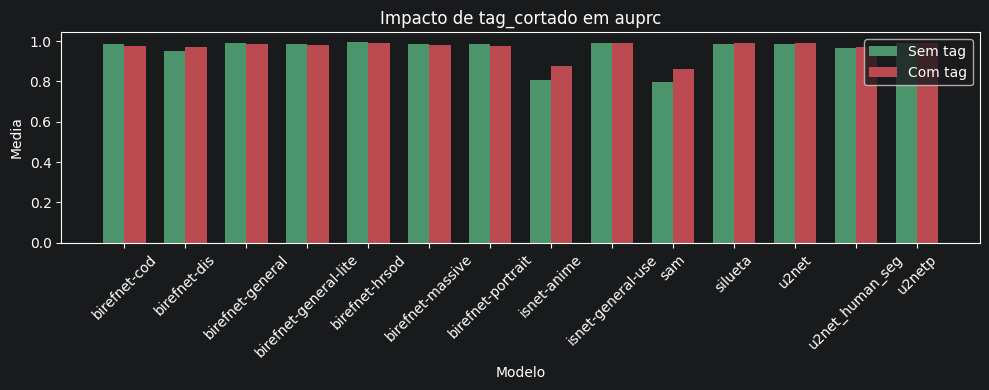

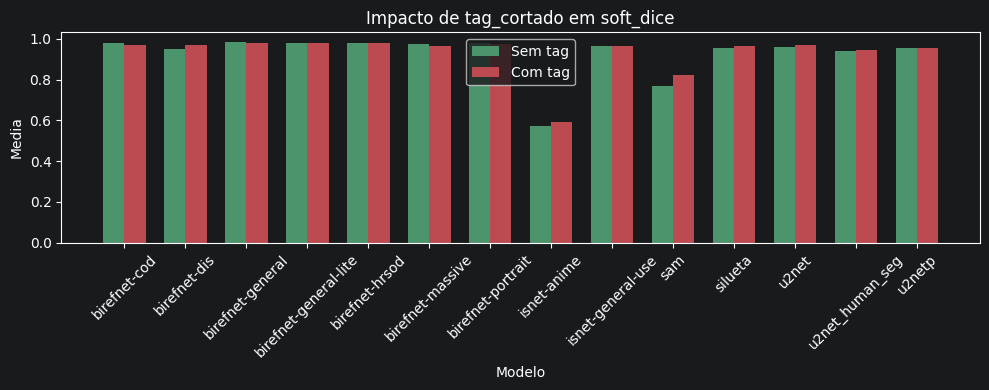

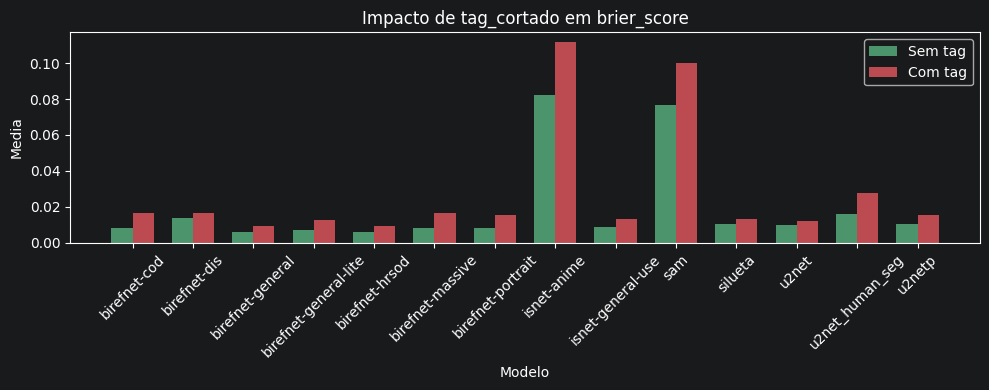

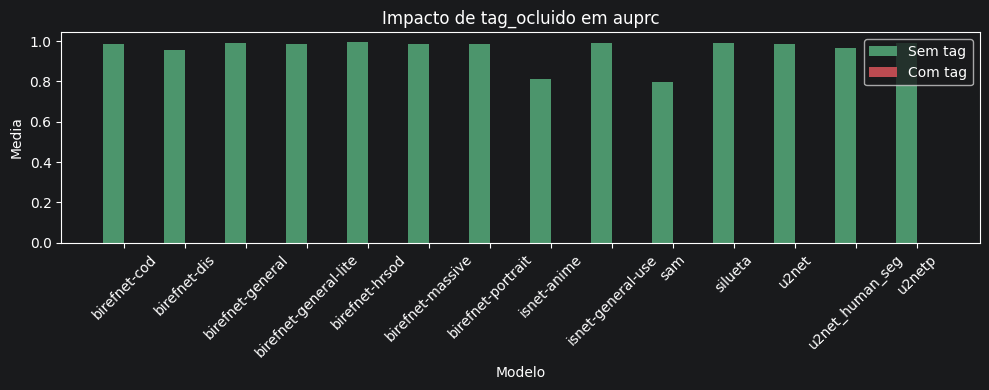

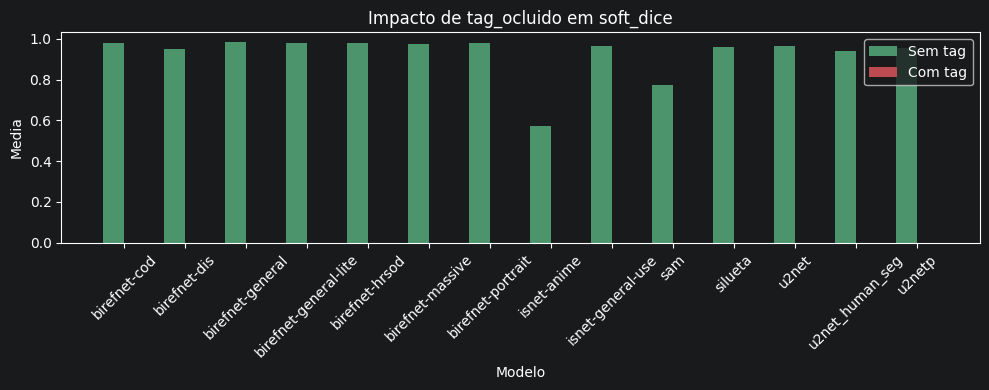

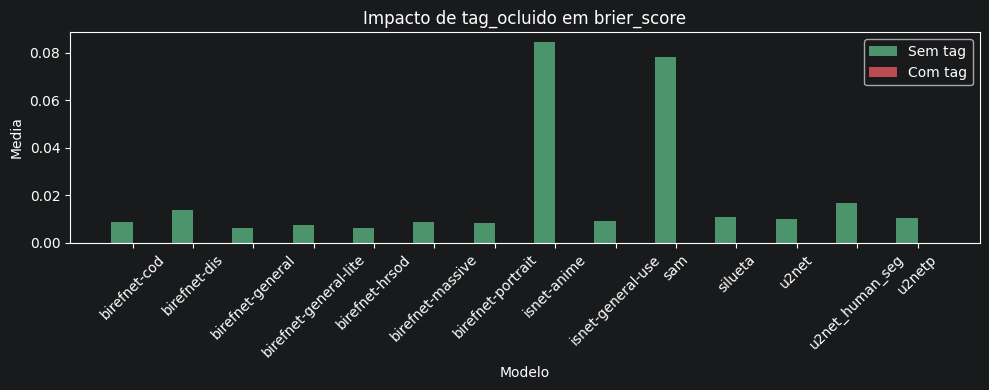

In [5]:
texto_impacto_tags = 'As tags entram como eixo explicativo do que degrada a segmentacao. O foco inicial esta nas tags mais provaveis de piorar a qualidade da mascara.'
figures_impacto_tags = []

display(
    df_resumo_tag.loc[
        df_resumo_tag['tag_name'].isin(tags_prioritarias),
        ['nome_modelo', 'tag_name', 'tag_value', 'metric_name', 'mean', 'median', 'count'],
    ].sort_values(['tag_name', 'nome_modelo', 'metric_name', 'tag_value'])
)

for tag_name in tags_prioritarias:
    for metric_name in metric_names:
        fig, _ = plot_metric_tag_comparison(df_resumo_tag, metric_name, tag_name)
        figures_impacto_tags.append(fig)
        plt.show()


## Distribuicao linha a linha

Os boxplots usam a base completa em memoria para mostrar dispersao e caudas, algo que os resumos persistidos nao capturam sozinhos.


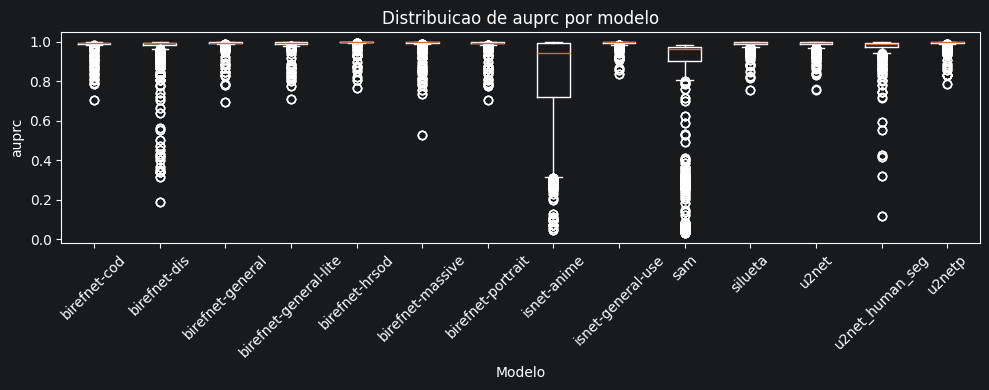

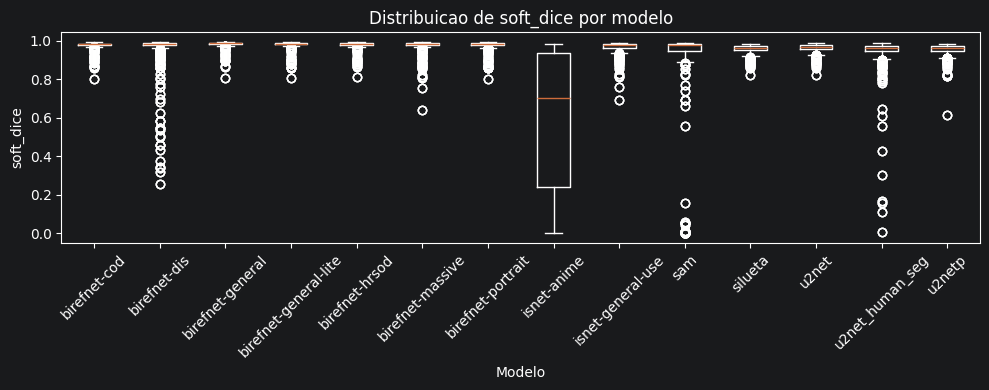

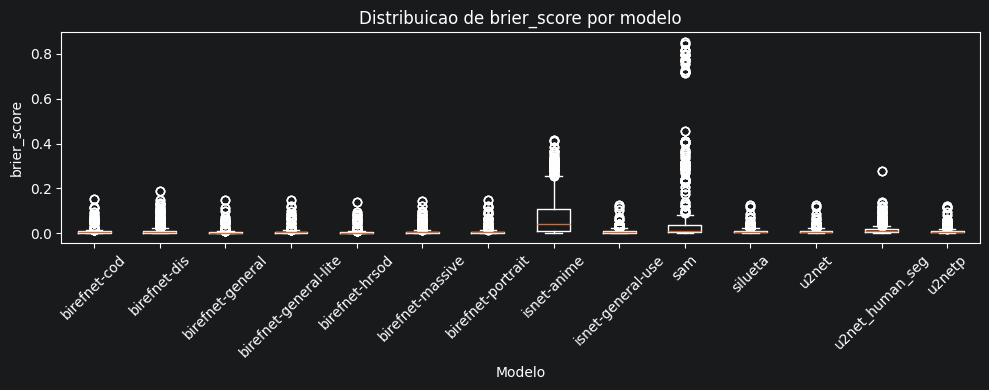

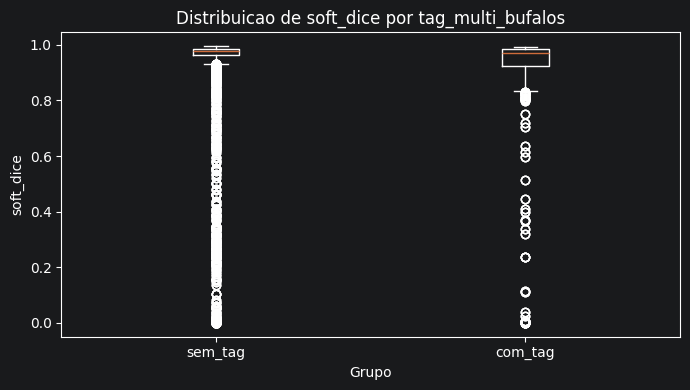

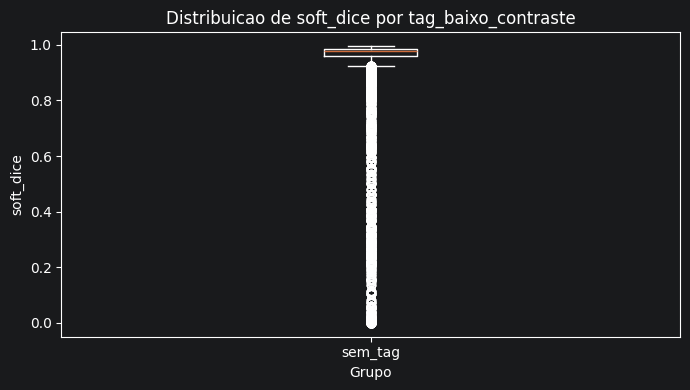

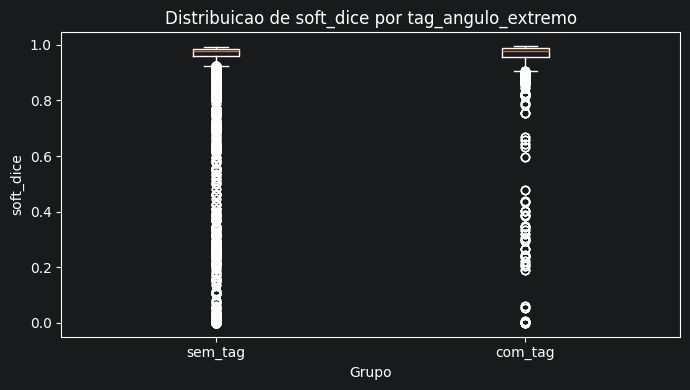

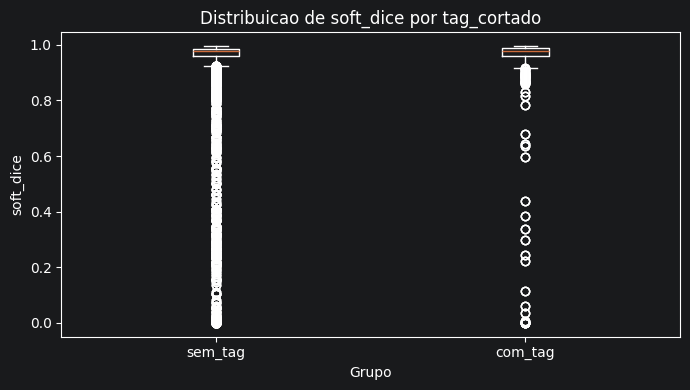

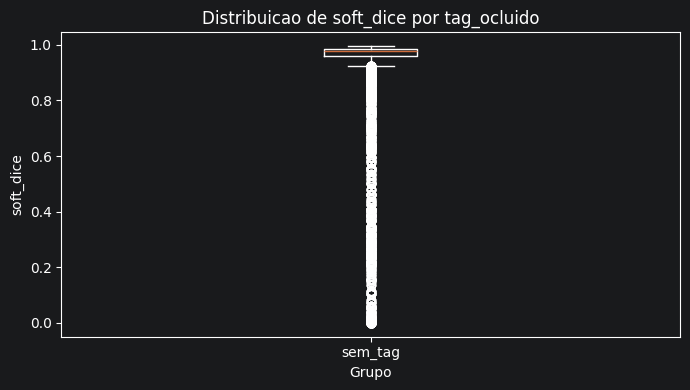

In [6]:
texto_distribuicao = 'Os boxplots usam a base completa em memoria para mostrar dispersao e caudas, algo que os resumos persistidos nao capturam sozinhos.'
figures_distribuicao = []

for metric_name in metric_names:
    fig, _ = plot_metric_distribution_by_model(df_base, metric_name)
    figures_distribuicao.append(fig)
    plt.show()

for tag_name in tags_prioritarias:
    fig, _ = plot_metric_distribution_by_tag(df_base, 'soft_dice', tag_name)
    figures_distribuicao.append(fig)
    plt.show()


## Leitura inicial

A combinacao entre medias por modelo, estabilidade por execucao, impacto das tags e distribuicao linha a linha ja permite responder quais modelos segmentam melhor e em que cenarios eles passam a falhar. A etapa seguinte continua sendo refinar os testes estatisticos no notebook 04 e aprofundar a leitura visual neste notebook 05.


In [7]:
report_sections = [
    PdfReportSection(
        heading='Carregamento dos resumos e da base linha a linha',
        body='Os resumos agregados sao lidos do SQLite. A base linha a linha e reconstruida apenas para os graficos de distribuicao.',
    ),
    PdfReportSection(
        heading='Visao geral por modelo',
        body=texto_visao_modelo,
        figures=figures_visao_modelo,
    ),
    PdfReportSection(
        heading='Estabilidade por execucao',
        body=texto_estabilidade_execucao,
        figures=figures_estabilidade_execucao,
    ),
    PdfReportSection(
        heading='Impacto das tags',
        body=texto_impacto_tags,
        figures=figures_impacto_tags,
    ),
    PdfReportSection(
        heading='Distribuicao linha a linha',
        body=texto_distribuicao,
        figures=figures_distribuicao,
    ),
    PdfReportSection(
        heading='Leitura inicial',
        body='A combinacao entre medias por modelo, estabilidade por execucao, impacto das tags e distribuicao linha a linha ja permite responder quais modelos segmentam melhor e em que cenarios eles passam a falhar. A etapa seguinte continua sendo refinar os testes estatisticos no notebook 04 e aprofundar a leitura visual neste notebook 05.',
    ),
]

pdf_path = save_pdf_report(
    output_path=report_output_path,
    sections=report_sections,
    report_title='05 - Visualizacao da Segmentacao Bruta',
)

print(f'Relatorio PDF salvo em: {pdf_path}')


Relatorio PDF salvo em: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/05_visualizacao_segmentacao_bruta.pdf
